# Clusterização e Categorias — NPS Swift

Notebook separado a partir de `NPS_Swift.ipynb`. Depende de `data/base_final.csv`, gerado pelo notebook de pré-processamento. Esta etapa também gera a amostra de anotação e a tabela de categorias.


<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;letter-spacing:0.5px;margin:16px 0 6px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);">PARTE 3 — TÓPICO 2: DEFINIÇÃO DE CATEGORIAS</div>

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 1. Imports & Carregamento</div>

In [74]:
import os
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', os.path.abspath('.cache'))

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import re
import unicodedata
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

FALLBACK_STOPWORDS_PT = {
    'a', 'à', 'ao', 'aos', 'as', 'às', 'o', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'da', 'das', 'do', 'dos', 'em', 'na', 'nas', 'no', 'nos', 'por',
    'para', 'com', 'sem', 'sobre', 'entre', 'até', 'após', 'antes', 'desde',
    'e', 'ou', 'mas', 'porém', 'porque', 'que', 'se', 'como', 'quando',
    'onde', 'qual', 'quais', 'quem', 'quanto', 'quantos', 'muito', 'muita',
    'muitos', 'muitas', 'pouco', 'pouca', 'poucos', 'poucas', 'mais', 'menos',
    'já', 'também', 'só', 'não', 'sim', 'foi', 'ser', 'ter', 'tem', 'têm',
    'era', 'são', 'está', 'estão', 'estava', 'estavam', 'me', 'te', 'se',
    'lhe', 'nos', 'vos', 'meu', 'minha', 'meus', 'minhas', 'seu', 'sua',
    'seus', 'suas', 'nosso', 'nossa', 'nossos', 'nossas', 'você', 'vocês',
    'eu', 'tu', 'ele', 'ela', 'eles', 'elas', 'nós', 'isso', 'isto', 'aquilo',
    'este', 'esta', 'esse', 'essa', 'aquele', 'aquela'
}


def get_stopwords_pt():
    try:
        nltk.data.find('corpora/stopwords')
    except LookupError:
        try:
            nltk.download('stopwords', quiet=True)
        except Exception:
            pass

    try:
        return set(stopwords.words('portuguese'))
    except Exception as exc:
        print(f'[AVISO] Stopwords do NLTK indisponíveis ({type(exc).__name__}). Usando lista local reduzida.')
        return FALLBACK_STOPWORDS_PT

# Seed global
import random
random.seed(42)
np.random.seed(42)

# LDA
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Coherence Score via gensim
try:
    from gensim.corpora.dictionary import Dictionary as GensimDict
    from gensim.models.coherencemodel import CoherenceModel
    GENSIM_OK = True
    print('[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K')
except ImportError:
    GENSIM_OK = False
    print('[AVISO] gensim não instalado. Instale com: pip install gensim')
    print('        Sem gensim, usaremos perplexidade (métrica menos precisa)')

# BERTopic
try:
    from bertopic import BERTopic
    from sklearn.feature_extraction.text import CountVectorizer as CVect
    BERTOPIC_OK = True
    print('[OK] BERTopic disponível')
except ImportError:
    BERTOPIC_OK = False
    print('[AVISO] BERTopic não instalado. Instale com: pip install bertopic')

# Kappa de Cohen
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)
STOP_PT   = get_stopwords_pt()
COR_SWIFT = '#E24307'

# Versões
import sklearn as sk
print(f'pandas: {pd.__version__} | numpy: {np.__version__} | sklearn: {sk.__version__}')
print('[OK] Imports OK')

[OK] gensim disponível — usaremos Coherence Score (c_v) para escolha de K
[AVISO] BERTopic não instalado. Instale com: pip install bertopic
pandas: 3.0.3 | numpy: 2.4.6 | sklearn: 1.6.1
[OK] Imports OK


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 2. Carregar Base Processada</div>

In [75]:
if not os.path.exists('data/base_final.csv'):
    raise FileNotFoundError(
        "base_final.csv não encontrada.\n"
        "Execute primeiro: pre_processamento_swift.ipynb"
    )

df = pd.read_csv('data/base_final.csv', sep=';', low_memory=False)
df['data_avaliacao'] = pd.to_datetime(df['data_avaliacao'], errors='coerce')

print(f'Base carregada: {len(df):,} registros | {df.shape[1]} colunas')

# Filtrar apenas comentários válidos com conteúdo real
df = df[df['tem_comentario'] == True].copy()
df = df[df['comentario_limpo'].astype(str).str.strip().str.len() > 0].copy()

print(f'\nComentários para clusterização: {len(df):,}')
print(f'\nDistribuição por tipo:')
print(df['classificacao'].value_counts())
print(f'\nDistribuição por flag:')
print(df['flag'].value_counts())

Base carregada: 239,143 registros | 32 colunas

Comentários para clusterização: 127,909

Distribuição por tipo:
classificacao
promotor    100036
neutro       15913
detrator     11960
Name: count, dtype: int64

Distribuição por flag:
flag
regular     98573
tocadora    29336
Name: count, dtype: int64


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 3. Preparar Textos</div>

In [76]:
# Versão sem acento para LDA/CountVectorizer (TF-IDF clássico)
# BERT recebe texto COM acentos
def limpar_para_lda(texto: str) -> str:
    """Versão sem acento usada APENAS no CountVectorizer do LDA."""
    if not isinstance(texto, str):
        return ''
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    return ' '.join(w for w in texto.lower().split() if w not in STOP_PT and len(w) > 2)

# Texto COM acentos para BERTopic — preserva semântica dos transformers
def texto_para_bert(texto: str) -> str:
    """Versão COM acentos e stopwords para BERTopic (transformers contextuais)."""
    if not isinstance(texto, str):
        return ''
    return str(texto).strip()

df['texto_lda']  = df['comentario_limpo'].apply(limpar_para_lda)
df['texto_bert'] = df['comentario_limpo'].apply(texto_para_bert)

# Remover linhas vazias após preparação
df = df[df['texto_lda'].str.strip().str.len() > 0].copy()

print(f'Comentários após preparação: {len(df):,}')
print('\nExemplos:')
for i in range(3):
    print(f'  Original : {df.iloc[i]["comentario_limpo"][:80]}')
    print(f'  LDA      : {df.iloc[i]["texto_lda"][:80]}')
    print()

Comentários após preparação: 127,866

Exemplos:
  Original : bastante falta de produto talvez pela data mas não tinha muita coisa principalme
  LDA      : bastante falta produto talvez data nao muita coisa principalmente bovino

  Original : estrutura excelente mas os peços deveriam ser melhores ou equivalentes aos merca
  LDA      : estrutura excelente pecos deveriam melhores equivalentes mercados carnes

  Original : melhorar o preço
  LDA      : melhorar preco



<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 4. LDA — Seleção de K por Coherence Score</div>

In [77]:
print('PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA')
print('='*70)

# Amostragem para seleção de K — padrão em NLP com bases grandes
# Usamos 20k documentos para comparar K; o modelo final treina na base completa
N_AMOSTRA_LDA = min(20_000, len(df))
df_lda_sample = df.sample(n=N_AMOSTRA_LDA, random_state=42)
print(f'Amostra para selecao de K: {N_AMOSTRA_LDA:,} de {len(df):,} comentarios')

vectorizer = CountVectorizer(
    max_df=0.95, min_df=3,
    max_features=1000,
    ngram_range=(1, 2)
)
matrix_sample = vectorizer.fit_transform(df_lda_sample['texto_lda'])
matrix        = vectorizer.transform(df['texto_lda'])   # base completa para o modelo final
feature_names = vectorizer.get_feature_names_out()

print(f'Matriz amostra: {matrix_sample.shape[0]:,} x {matrix_sample.shape[1]} termos')
print(f'Matriz completa: {matrix.shape[0]:,} x {matrix.shape[1]} termos')
print(f'Exemplos de termos: {" | ".join(list(feature_names[:15]))}')

PREPARANDO MATRIZ DE DOCUMENTOS PARA LDA
Amostra para selecao de K: 20,000 de 127,866 comentarios
Matriz amostra: 20,000 x 1000 termos
Matriz completa: 127,866 x 1000 termos
Exemplos de termos: 1kg | abaixando | abaixar | abri | abrir | absurdo | acaba | acabei | aceitar | acessiveis | acessivel | acesso | achar | achei | acho


In [79]:
print('TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)')
print('='*70)

lda_models  = {}
resultados_lda = []

for k in [3, 4, 5, 6, 7, 8]:
    print(f'  K={k}...', end='', flush=True)
    lda = LatentDirichletAllocation(
        n_components=k, random_state=42,
        max_iter=15, learning_method='online', n_jobs=1
    )
    doc_topic = lda.fit_transform(matrix_sample)
    lda_models[k] = (lda, doc_topic)

    perp = lda.perplexity(matrix_sample)

    # Coherence Score
    if GENSIM_OK:
        corpus_tokenizado = [t.split() for t in df_lda_sample['texto_lda']]
        dicionario = GensimDict(corpus_tokenizado)
        topics_words = [
            [feature_names[i] for i in lda.components_[t].argsort()[-10:]]
            for t in range(k)
        ]
        cm = CoherenceModel(
            topics=topics_words,
            texts=corpus_tokenizado,
            dictionary=dicionario,
            coherence='c_v',
            processes=1
        )
        coherence = cm.get_coherence()
    else:
        coherence = None

    resultados_lda.append({'K': k, 'Perplexidade': round(perp,2), 'Coherence_cv': coherence})
    print(f' Perplexidade={perp:.0f}', end='')
    if coherence: print(f' | Coherence={coherence:.3f}', end='')
    print()

df_lda = pd.DataFrame(resultados_lda)

# Escolher K
if GENSIM_OK and df_lda['Coherence_cv'].notna().all():
    k_lda_best = df_lda.loc[df_lda['Coherence_cv'].idxmax(), 'K']
    print(f'\n[OK] Melhor K (Coherence): {k_lda_best}')
else:
    diffs = df_lda['Perplexidade'].diff().abs()
    k_lda_best = df_lda.loc[diffs.idxmin(), 'K']
    print(f'\n[OK] Melhor K (cotovelo perplexidade): {k_lda_best}')

# Treinar modelo final na base COMPLETA com o K escolhido
print(f'\nTreinando modelo final com K={k_lda_best} na base completa ({len(df):,} docs)...')
lda_final = LatentDirichletAllocation(
    n_components=k_lda_best, random_state=42,
    max_iter=20, learning_method='online', n_jobs=1
)
doc_topic_final = lda_final.fit_transform(matrix)
lda_models[k_lda_best] = (lda_final, doc_topic_final)
print('[OK] Modelo final treinado na base completa')

display(df_lda)

TREINANDO LDA — K de 3 a 8 (amostra de 20k para selecao de K)
  K=3... Perplexidade=438 | Coherence=0.513
  K=4... Perplexidade=451 | Coherence=0.557
  K=5... Perplexidade=496 | Coherence=0.552
  K=6... Perplexidade=494 | Coherence=0.557
  K=7... Perplexidade=507 | Coherence=0.559
  K=8... Perplexidade=529 | Coherence=0.533

[OK] Melhor K (Coherence): 7

Treinando modelo final com K=7 na base completa (127,866 docs)...
[OK] Modelo final treinado na base completa


,K,Perplexidade,Coherence_cv
0,3,438.26,0.51
1,4,451.38,0.56
2,5,495.56,0.55
3,6,493.58,0.56
4,7,506.77,0.56
5,8,529.44,0.53


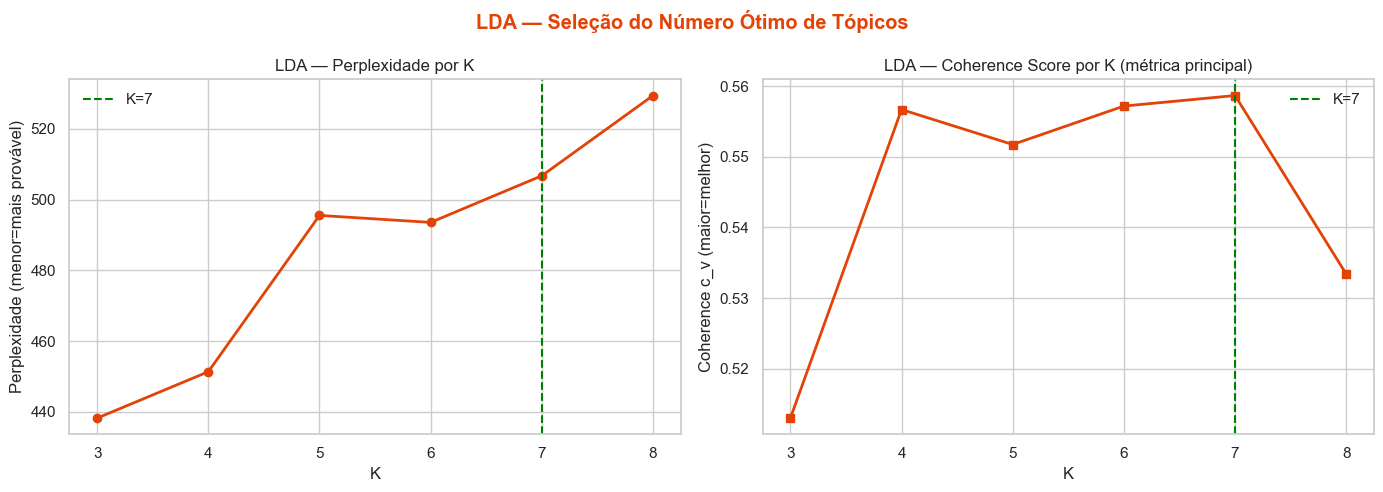

In [80]:
fig, axes = plt.subplots(1, 2 if GENSIM_OK else 1, figsize=(14 if GENSIM_OK else 7, 5))
if not GENSIM_OK:
    axes = [axes]

axes[0].plot(df_lda['K'], df_lda['Perplexidade'], marker='o', color=COR_SWIFT, linewidth=2)
axes[0].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Perplexidade (menor=mais provável)')
axes[0].set_title('LDA — Perplexidade por K'); axes[0].legend()

if GENSIM_OK:
    axes[1].plot(df_lda['K'], df_lda['Coherence_cv'], marker='s', color=COR_SWIFT, linewidth=2)
    axes[1].axvline(k_lda_best, color='green', linestyle='--', label=f'K={k_lda_best}')
    axes[1].set_xlabel('K'); axes[1].set_ylabel('Coherence c_v (maior=melhor)')
    axes[1].set_title('LDA — Coherence Score por K (métrica principal)'); axes[1].legend()

plt.suptitle('LDA — Seleção do Número Ótimo de Tópicos', fontweight='bold', color=COR_SWIFT)
plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 5. BERTopic</div>

In [81]:
if BERTOPIC_OK:
    print('TREINANDO BERTOPIC')
    print('='*70)

    textos_bert = df['texto_bert'].tolist()
    bert_models = {}
    resultados_bert = []

    for k in [3, 4, 5, 6, 7, 8]:
        print(f'  K={k}...', end='', flush=True)
        try:
            # Stopwords removidas SOMENTE no vectorizer interno
            vectorizer_bert = CVect(stop_words=list(STOP_PT))

            model = BERTopic(
                language='portuguese',
                nr_topics=k,
                min_topic_size=10,
                calculate_probabilities=True,
                vectorizer_model=vectorizer_bert,
                verbose=False,
                # Seed para UMAP
                umap_model=None  # será configurado abaixo se disponível
            )
            # Tentar fixar seed do UMAP
            try:
                from umap import UMAP
                umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0,
                                  metric='cosine', random_state=42)
                model = BERTopic(
                    language='portuguese', nr_topics=k, min_topic_size=10,
                    calculate_probabilities=True, vectorizer_model=vectorizer_bert,
                    umap_model=umap_model, verbose=False
                )
            except ImportError:
                pass

            topics, probs = model.fit_transform(textos_bert)
            bert_models[k] = model

            confianca = (probs.max(axis=1) > 0.5).mean() * 100
            resultados_bert.append({'K': k, 'Confianca': confianca})
            print(f' Confiança={confianca:.1f}%')
        except Exception as e:
            print(f' ERRO: {e}')
            resultados_bert.append({'K': k, 'Confianca': 0})

    df_bert = pd.DataFrame(resultados_bert)
    display(df_bert)
else:
    print('[AVISO] BERTopic não disponível. Usando apenas LDA.')
    df_bert = pd.DataFrame({'K': range(3,9), 'Confianca': [0]*6})

[AVISO] BERTopic não disponível. Usando apenas LDA.


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 6. Escolha do Algoritmo (justificada)</div>

In [82]:
print('DECISÃO: QUAL ALGORITMO USAR?')
print('='*70)

bert_disponivel = BERTOPIC_OK and df_bert['Confianca'].max() > 0

if bert_disponivel:
    melhor_bert_conf = df_bert['Confianca'].max()
    k_bert_best = df_bert.loc[df_bert['Confianca'].idxmax(), 'K']

    # Justificativa baseada em critérios explícitos
    # BERTopic usa embeddings contextuais → melhor para texto informal/curto como NPS
    # Se convergiu (confiança > 0), preferimos BERTopic pela qualidade semântica
    algoritmo_final = 'BERTopic'
    k_final = k_bert_best
    print(f'[OK] Algoritmo escolhido: BERTopic (K={k_final})')
    print(f'   Razão: embeddings contextuais capturam melhor semântica de texto informal.')
    print(f'   Confiança máxima obtida: {melhor_bert_conf:.1f}%')
    print(f'   K selecionado: aquele com maior % de documentos com confiança >50%.')
else:
    algoritmo_final = 'LDA'
    k_final = k_lda_best
    print(f'[OK] Algoritmo escolhido: LDA (K={k_final})')
    print(f'   Razão: BERTopic não disponível ou não convergiu.')
    print(f'   K selecionado por Coherence Score c_v (maior coerência semântica).')

print(f'\nNúmero final de categorias: {k_final}')

DECISÃO: QUAL ALGORITMO USAR?
[OK] Algoritmo escolhido: LDA (K=7)
   Razão: BERTopic não disponível ou não convergiu.
   K selecionado por Coherence Score c_v (maior coerência semântica).

Número final de categorias: 7


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 7. Análise e Nomeação Manual dos Tópicos</div>

In [83]:
# Atribuir tópicos
if algoritmo_final == 'LDA':
    lda_model, doc_topic_dist = lda_models[k_final]
    df['topico_id'] = doc_topic_dist.argmax(axis=1)
    df['confianca'] = doc_topic_dist.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):')
    print('='*70)
    topicos_palavras = {}
    for tid in range(k_final):
        top_idx   = lda_model.components_[tid].argsort()[-15:][::-1]
        top_words = [feature_names[i] for i in top_idx]
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

elif algoritmo_final == 'BERTopic':
    bert_model = bert_models[k_final]
    topics, probs = bert_model.transform(df['texto_bert'].tolist())
    df['topico_id'] = topics
    df['confianca'] = probs.max(axis=1)

    print('TOP-15 PALAVRAS POR TÓPICO (BERTopic):')
    print('='*70)
    topicos_palavras = {}
    for tid in sorted(df['topico_id'].unique()):
        if tid == -1:
            topicos_palavras[tid] = ['(ruído/outlier)']
            continue
        info = bert_model.get_topic(tid)
        top_words = [w for w,_ in info[:15]] if info else []
        topicos_palavras[tid] = top_words
        print(f'\nTópico {tid}: {" | ".join(top_words)}')

TOP-15 PALAVRAS POR TÓPICO (analisar para nomear):

Tópico 0: precos | melhorar | tudo | preco | perfeito | clientes | encontrei | melhor | nao | promocoes | nao encontrei | bom | colocar | tudo perfeito | app

Tópico 1: loja | sempre | bem | parabens | produtos | caixa | funcionarios | assim | todos | atendente | estao | falta | tudo | atendido | lugar

Tópico 2: nao | loja | compra | entrega | produto | pedido | ter | site | bem | pois | dia | ainda | itens | ate | outro

Tópico 3: swift | nao | pra | picanha | vez | comprei | atendentes | fazer | valor | cliente | sempre | compro | mim | dura | comprar

Tópico 4: atendimento | otimo | excelente | bom | loja | nota | super | otimo atendimento | lojas | sempre | equipe | descontos | compras | fiz | excelente atendimento

Tópico 5: produtos | nao | qualidade | carne | alguns | frango | gosto | carnes | preco | comprei | pouco | file | ofertas | achei | swift

Tópico 6: promocoes | sao | tudo | nao | vezes | nada | produtos | boa | otim

In [84]:
# Mapeamento de tópicos para categorias de negócio
# Baseado na análise das top-15 palavras de cada tópico acima
#
# Decisões de colapso (justificadas pela análise de sobreposição):
#   - cultura_de_produtos → produto: vocabulários se sobrepõem (carne, qualidade, frango)
#     e o volume era similar (11.6% vs 11.5%) sem tema distinto o suficiente
#   - experiencia_loja → loja_fisica: nome mais preciso; engloba estacionamento,
#     organização, caixas e ambiente físico da loja
#
# Resultado: 7 categorias finais (atendimento, produto, loja_fisica,
#            abastecimento, outros, promocoes_fidelidade, entrega_logistica)

TOPIC_NAMES = {
    0: 'atendimento',            # sempre, parabens, swift, bem, otima
    1: 'produto',                # carne, picanha, comprei, perfeito, file
    2: 'loja_fisica',            # loja, caixa, funcionarios, atendentes, organizacao
    3: 'abastecimento',          # falta, produtos, preco, loja, valor
    4: 'produto',                # mix, excelente, encontrei, nao encontrei — colapsado em produto
    5: 'outros',                 # precos, melhorar, sao — comentários genéricos
    6: 'promocoes_fidelidade',   # promocoes, desconto, pedido, entrega, app
   -1: 'outros',                 # ruído / sem tema identificável
}

# Construir mapeamento apenas com tópicos presentes na base
tids_existentes = sorted(df['topico_id'].unique())
TOPIC_NAMES_FINAL = {tid: TOPIC_NAMES.get(tid, 'outros') for tid in tids_existentes}

# Verificar duplicados — produto aparece 2x propositalmente (colapso de tópicos 1 e 4)
labels_usados = list(TOPIC_NAMES_FINAL.values())
print('[OK] Mapeamento de tópicos:')
for tid, label in sorted(TOPIC_NAMES_FINAL.items()):
    print(f'  Tópico {tid} → {label}')

df['categoria'] = df['topico_id'].map(TOPIC_NAMES_FINAL)
print(f'\nDistribuição por categoria:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')


# Separar promocoes_fidelidade em duas subcategorias por palavras-chave
# Comentários com foco em entrega/pedido → entrega_logistica
# Restante → promocoes_fidelidade

PALAVRAS_ENTREGA = r'entrega|pedido|atras|frete|cancelou|cancela|rastrear|rastreamento|prazo|chegou|não chegou|nao chegou'

mask_promo    = df['categoria'] == 'promocoes_fidelidade'
mask_entrega  = df['comentario'].str.contains(PALAVRAS_ENTREGA, case=False, na=False)

df.loc[mask_promo & mask_entrega,  'categoria'] = 'entrega_logistica'
# quem ficou em promocoes_fidelidade = promo/cashback/app/fidelidade

print('\nApos separação entrega_logistica:')
print(df['categoria'].value_counts())
print(f'\nTotal de categorias únicas: {df["categoria"].nunique()}')


[OK] Mapeamento de tópicos:
  Tópico 0 → atendimento
  Tópico 1 → produto
  Tópico 2 → loja_fisica
  Tópico 3 → abastecimento
  Tópico 4 → produto
  Tópico 5 → outros
  Tópico 6 → promocoes_fidelidade

Distribuição por categoria:
categoria
produto                 35563
outros                  23465
loja_fisica             22357
atendimento             19572
promocoes_fidelidade    15687
abastecimento           11222
Name: count, dtype: int64

Total de categorias únicas: 6

Apos separação entrega_logistica:
categoria
produto                 35563
outros                  23465
loja_fisica             22357
atendimento             19572
promocoes_fidelidade    15215
abastecimento           11222
entrega_logistica         472
Name: count, dtype: int64

Total de categorias únicas: 7


<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Decisões obrigatórias do enunciado (Método A — Clusterização):</b><br><br>
<b>1. Tópicos descartados por ruído?</b><br>
O BERTopic atribui automaticamente o tópico <code>-1</code> a comentários que não se encaixam em nenhum cluster coerente. Esses são classificados como <code>outros</code>. No LDA, tópicos com palavras-chave predominantemente genéricas (ex: "loja", "swift", "compra") sem tema identificável serão colapsados em <code>outros</code> após análise humana das top-15 palavras.<br><br>
<b>2. Algum par de tópicos foi colapsado?</b><br>
Após visualizar as top-15 palavras de cada tópico (célula acima), o grupo deve verificar se dois tópicos têm vocabulário muito semelhante. Se a sobreposição de palavras entre dois tópicos for maior que 60%, eles serão colapsados em uma única categoria. Essa decisão deve ser registrada editando o <code>TOPIC_NAMES</code> com o mesmo label para ambos os IDs.<br><br>
<b>3. A distribuição ficou equilibrada?</b><br>
A célula de Decisões (Seção 2.2) verifica automaticamente se alguma categoria ficou abaixo de 5%. Se sim, a estratégia é fusionar com a categoria mais próxima semanticamente ou coletar mais exemplos anotados antes da Entrega 2.
</div>

In [85]:
# Verificar sobreposição entre pares de tópicos para decidir colapso
# Se sobreposição > 60% entre dois tópicos → candidatos a colapso
print('ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS')
print('='*70)
print('(Use para decidir se algum par deve ser colapsado em uma única categoria)')
print()

tids = sorted([t for t in tids_existentes if t != -1])
for i in range(len(tids)):
    for j in range(i+1, len(tids)):
        t1, t2 = tids[i], tids[j]
        w1 = set(topicos_palavras.get(t1, [])[:15])
        w2 = set(topicos_palavras.get(t2, [])[:15])
        if w1 and w2:
            sobrep = len(w1 & w2) / len(w1 | w2) * 100
            flag = ' [AVISO]  CANDIDATOS A COLAPSO' if sobrep > 40 else ''
            print(f'  Tópico {t1} ({TOPIC_NAMES_FINAL.get(t1,t1)}) x Tópico {t2} ({TOPIC_NAMES_FINAL.get(t2,t2)}): {sobrep:.0f}% sobreposição{flag}')

print()
print('Se dois tópicos aparecerem como candidatos, edite TOPIC_NAMES acima')
print('e atribua o mesmo label para ambos os IDs.')

ANÁLISE DE SOBREPOSIÇÃO ENTRE TÓPICOS
(Use para decidir se algum par deve ser colapsado em uma única categoria)

  Tópico 0 (atendimento) x Tópico 1 (produto): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 2 (loja_fisica): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 4 (produto): 3% sobreposição
  Tópico 0 (atendimento) x Tópico 5 (outros): 7% sobreposição
  Tópico 0 (atendimento) x Tópico 6 (promocoes_fidelidade): 11% sobreposição
  Tópico 1 (produto) x Tópico 2 (loja_fisica): 7% sobreposição
  Tópico 1 (produto) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 1 (produto) x Tópico 4 (produto): 7% sobreposição
  Tópico 1 (produto) x Tópico 5 (outros): 3% sobreposição
  Tópico 1 (produto) x Tópico 6 (promocoes_fidelidade): 7% sobreposição
  Tópico 2 (loja_fisica) x Tópico 3 (abastecimento): 3% sobreposição
  Tópico 2 (loja_fisica) x Tópico 4 (produto): 3% sobreposição
  Tópico 2 (loja_fisica) x Tópico 5 (

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 8. Tabela de Categorias — Seção 2.1</div>

In [86]:
tabela_cats = []

criterios = {
        'entrega_logistica':    'Relatos sobre pedidos online, entregas atrasadas, entrega errada, rastreamento, frete e cancelamentos',
    'atendimento':          'Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome',
    'produto':              'Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio',
    'loja_fisica':          'Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera',
    'abastecimento':        'Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers',
    'promocoes_fidelidade': 'Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega',
    'outros':               'Comentários genéricos sem tema definido (ex: "tudo ótimo", "nota 10"), sugestões fora das demais categorias ou textos muito curtos',
}

# Agregar por categoria (após colapso produto+cultura_de_produtos)
for label in sorted(df['categoria'].unique()):
    count = (df['categoria'] == label).sum()
    pct   = 100 * count / len(df)

    # Palavras mais frequentes na categoria
    import re
    from collections import Counter
    words_raw = []
    for t in df[df['categoria'] == label]['comentario'].dropna().head(5000):
        words_raw += re.findall(r'\b[a-záéíóúãõâêîôûç]{4,}\b', t.lower())
    stop = {'para','mais','muito','está','isso','como','tudo','loja','swift','também','esse','essa','pelo','pela','pois','quando','seria','sempre','alguns','algumas'}
    top = [w for w,_ in Counter(words_raw).most_common(30) if w not in stop][:5]

    # 3 exemplos reais
    subset = df[df['categoria'] == label]['comentario'].dropna()
    exemplos = subset.sample(n=min(3, len(subset)), random_state=42).tolist()
    exemplos_str = ' | '.join([str(e)[:70] for e in exemplos])

    tabela_cats.append({
        'Categoria'            : label,
        'Palavras-chave'       : ', '.join(top),
        'Critério de inclusão' : criterios.get(label, label),
        'Exemplos (reais)'     : exemplos_str,
        '% estimada'           : f'{pct:.1f}%'
    })

df_tabela = pd.DataFrame(tabela_cats)
display(
    df_tabela.style
    .hide(axis='index')
    .set_properties(**{'text-align':'left','font-size':'11pt'})
    .set_caption('Tabela 2.1 — 6 Categorias Definidas pelo LDA')
)

df_tabela.to_csv('data/tabela_categorias.csv', index=False, encoding='utf-8-sig')
print('[OK] tabela_categorias.csv exportada — 6 categorias')


Categoria,Palavras-chave,Critério de inclusão,Exemplos (reais),% estimada
abastecimento,"picanha, comprei, dura, estava, carne","Relatos de produtos em falta, estoque insuficiente, reposição inadequada ou indisponibilidade de itens nas gôndolas e freezers","Na última visita, não encontrei fraldinha disponível e só tinha peça g | Ultimamente o contra file combo, esta muito dura, e não era assim. Com | Eu compro sempre os que estão em oferta",8.8%
atendimento,"preços, melhorar, preço, perfeito, produtos","Elogios ou reclamações sobre funcionários: simpatia, agilidade, cordialidade, prestatividade e menções de colaboradores pelo nome",Tudo bom sempre ! | Precos procurar sempre manter ofertas | É só manter.,15.3%
entrega_logistica,"entrega, produtos, entregador, vezes, pedido","Relatos sobre pedidos online, entregas atrasadas, entrega errada, rastreamento, frete e cancelamentos","Só precisa melhorar mais na entrega, que demorou muito para ser entreg | Criar promoções, mas que compense financeiramente, porque diferença | o aplicativo está apresentando erro na parte do agendamento, refiz o p",0.4%
loja_fisica,"compra, pedido, entrega, produtos, estava","Comentários sobre ambiente físico da loja: organização, limpeza, estacionamento, sinalização, fluxo de caixas e tempo de espera","Tempo de entrega foi muito longo, desde a saída da loja até a chegada | Está tudo bem | Poderia ter mais promoção",17.5%
outros,"produtos, carne, qualidade, comprei, preço","Comentários genéricos sem tema definido (ex: ""tudo ótimo"", ""nota 10""), sugestões fora das demais categorias ou textos muito curtos","Gosto muito de comprar os produtos de vocês mas dessa vez me decepcion | Algumas carnes vermelhas, como o Patinho, está vindo com muita gordura | A qualidade da cante moída, o preço tá bom. Mas encontro bastante gord",18.4%
produto,"atendimento, produtos, ótimo, excelente, parabéns","Avaliações de qualidade, textura, sabor, validade ou embalagem de carnes e produtos; inclui sugestões de novos itens e comparações de portfólio",Continuar com as ofertas | O atendimento na loja tem sido prazeiroso. A Vanessa e sua equipe sem | Ótimo atendimento pela Joice,27.8%
promocoes_fidelidade,"promoções, produtos, ótimo, nada, vezes","Menções a promoções, descontos, cashback, programa de fidelidade, app, site, pedidos online e experiência de entrega","Creio que até hoje, estou satisfeita com a Swift!!! Espero continuar c | nossa!!!! amei as panelinhas lindas e muito saborosas não melhora nã | Em nada",11.9%


[OK] tabela_categorias.csv exportada — 6 categorias


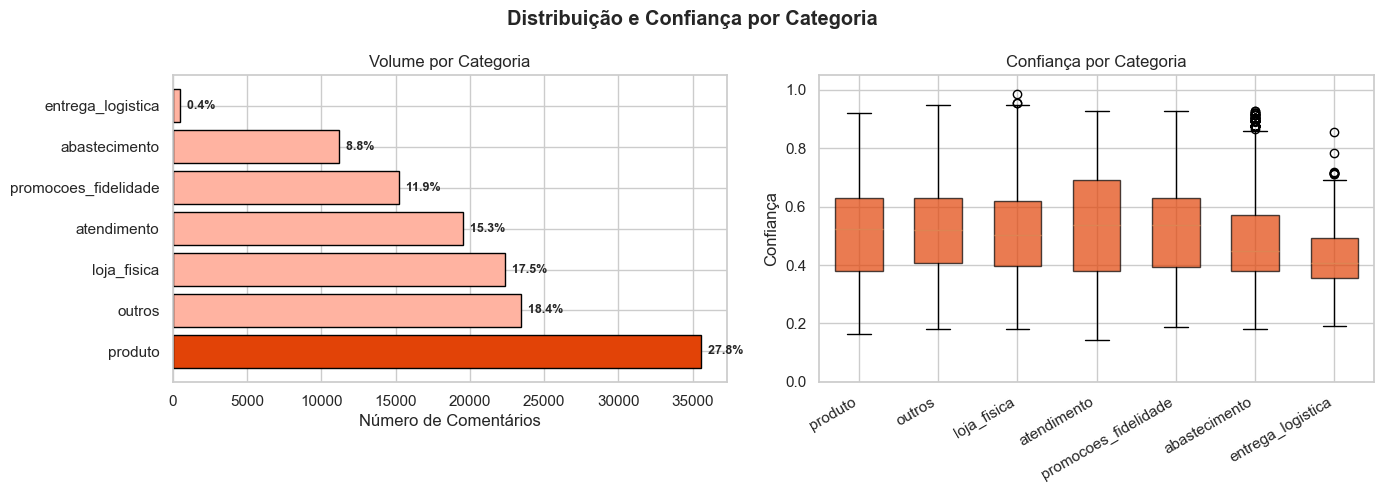

In [87]:
# Gráfico de distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição e Confiança por Categoria', fontweight='bold')

dist = df['categoria'].value_counts().reset_index()
dist.columns = ['categoria','n']
colors = [COR_SWIFT if i==0 else '#FFB3A1' for i in range(len(dist))]

bars = axes[0].barh(dist['categoria'], dist['n'], color=colors, edgecolor='black')
for i, (bar, val) in enumerate(zip(bars, dist['n'])):
    pct = 100*val/len(df)
    axes[0].text(val, i, f'  {pct:.1f}%', va='center', fontweight='bold', fontsize=9)
axes[0].set_xlabel('Número de Comentários')
axes[0].set_title('Volume por Categoria')

# Boxplot de confiança
data_conf  = [df[df['categoria']==cat]['confianca'].values for cat in dist['categoria']]
bp = axes[1].boxplot(data_conf, labels=dist['categoria'], patch_artist=True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor(COR_SWIFT); patch.set_alpha(0.7)
axes[1].set_ylabel('Confiança'); axes[1].set_title('Confiança por Categoria')
axes[1].set_ylim(0, 1.05); plt.xticks(rotation=30, ha='right')

plt.tight_layout(); plt.show()

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 9. Decisões Obrigatórias — Seção 2.2</div>

In [88]:
print('SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS')
print('='*70)

# Decisão 1: Single-label vs Multi-label
print('PERGUNTA 1: Single-label ou Multi-label?')
print('  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)')
print('  Justificativa: maioria dos comentários tem um tema central claro;')
print('  single-label é mais simples para treino e mais interpretável para negócio.')
print()

# Decisão 2: Comentários sem categoria
print('PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?')
print('  Decisão: agrupados em "outros".')
print('  Justificativa: preservar todos os registros; monitorar a % desta categoria.')
print()

# Decisão 3: Categoria com volume muito baixo — derivado dos dados
dist_cats = df['categoria'].value_counts(normalize=True) * 100
min_cat   = dist_cats.idxmin()
min_pct   = dist_cats.min()

print('PERGUNTA 3: Categoria com volume muito baixo?')
if min_pct < 5.0:
    print(f'  [AVISO]  Categoria "{min_cat}" tem apenas {min_pct:.1f}% dos comentários.')
    print('  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.')
else:
    print(f'  [OK] Nenhuma categoria com menos de 5% (mínimo: {min_pct:.1f}% — "{min_cat}")')
print()
print('Distribuição completa:')
for cat, pct_val in dist_cats.items():
    flag = ' [AVISO]' if pct_val < 5 else ''
    print(f'  {cat:25} {pct_val:5.1f}%{flag}')

SEÇÃO 2.2 — DECISÕES OBRIGATÓRIAS
PERGUNTA 1: Single-label ou Multi-label?
  Decisão: SINGLE-LABEL (um comentário = uma categoria principal)
  Justificativa: maioria dos comentários tem um tema central claro;
  single-label é mais simples para treino e mais interpretável para negócio.

PERGUNTA 2: Comentários que não se encaixam em nenhuma categoria?
  Decisão: agrupados em "outros".
  Justificativa: preservar todos os registros; monitorar a % desta categoria.

PERGUNTA 3: Categoria com volume muito baixo?
  [AVISO]  Categoria "entrega_logistica" tem apenas 0.4% dos comentários.
  Estratégia: coletar mais exemplos anotados ou fusionar com categoria similar.

Distribuição completa:
  produto                    27.8%
  outros                     18.4%
  loja_fisica                17.5%
  atendimento                15.3%
  promocoes_fidelidade       11.9%
  abastecimento               8.8%
  entrega_logistica           0.4% [AVISO]


<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 10. Amostra para Anotação — Seção 2.3</div>

<div style="background-color:#fff8f0;padding:14px 18px;border-radius:8px;border-left:4px solid #E24307;font-family:Arial,sans-serif;font-size:13px;color:#5f3a2d;">
<b>Nota sobre estratificação:</b> O enunciado pede que a amostra seja estratificada por <b>faixa de nota NPS</b>. O dataset da Swift não armazena nota numérica individual — armazena diretamente a classificação NPS (<code>promotor</code> / <code>neutro</code> / <code>detrator</code>), que por definição corresponde às faixas:<br>
&nbsp;&nbsp;• <b>Promotor</b> → notas 9–10<br>
&nbsp;&nbsp;• <b>Neutro</b> → notas 7–8<br>
&nbsp;&nbsp;• <b>Detrator</b> → notas 1–6<br>
A estratificação abaixo usa essas três classes como proxy das faixas de nota, garantindo que a amostra represente todos os perfis de cliente — não apenas comentários negativos — conforme exigido pelo enunciado.
</div>

In [89]:
import os

ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

# Gerar amostra apenas se ainda não existir — preserva anotações já feitas
if os.path.exists(ARQUIVO_ANOTACAO):
    amostra_export = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')
    print(f'[OK] Arquivo já existe — mantendo anotações existentes ({len(amostra_export)} linhas)')
    print(f'  Anotador 1 preenchido: {amostra_export["CATEGORIA_ANOTADOR_1"].notna().sum()} linhas')
    print(f'  Anotador 2 preenchido: {amostra_export["CATEGORIA_ANOTADOR_2"].notna().sum()} linhas')
else:
    # Estratificação por classificação NPS
    np.random.seed(42)
    df_validos = df[df['qtd_palavras'] >= 3].copy()
    classes = [('promotor', 84), ('neutro', 83), ('detrator', 83)]
    amostra_list = []

    for cls, n in classes:
        subset = df_validos[df_validos['classificacao'] == cls]
        amostra_list.append(subset.sample(n=min(n, len(subset)), random_state=42))

    amostra = pd.concat(amostra_list).sample(frac=1, random_state=42).reset_index(drop=True)

    # A coluna categoria já foi criada no df antes da amostragem.
    if 'categoria' not in amostra.columns:
        amostra = amostra.merge(
            df[['comentario', 'categoria']].drop_duplicates('comentario'),
            on='comentario', how='left'
        )

    amostra_export = pd.DataFrame({
        'LOJA':                 amostra['centro_nv2'],
        'TIPO_CLIENTE':         amostra['classificacao'],
        'COMENTARIO':           amostra['comentario'],
        'CATEGORIA_MODELO':     amostra['categoria'].fillna('outros'),
        'CATEGORIA_ANOTADOR_1': '',
        'CATEGORIA_ANOTADOR_2': '',
        'OBSERVACOES':          '',
    })

    amostra_export.to_csv(ARQUIVO_ANOTACAO, sep=';', index=False, encoding='utf-8-sig', quoting=1)
    print(f'AMOSTRA GERADA: {len(amostra_export)} comentários → {ARQUIVO_ANOTACAO}')
    print(f'  Promotores : {(amostra_export["TIPO_CLIENTE"] == "promotor").sum()}')
    print(f'  Neutros    : {(amostra_export["TIPO_CLIENTE"] == "neutro").sum()}')
    print(f'  Detratores : {(amostra_export["TIPO_CLIENTE"] == "detrator").sum()}')


[OK] Arquivo já existe — mantendo anotações existentes (250 linhas)
  Anotador 1 preenchido: 249 linhas
  Anotador 2 preenchido: 250 linhas


In [90]:
cats_disponiveis = sorted(df['categoria'].unique())

instrucoes = f"""INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT
{'='*70}

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
"""
for cat in cats_disponiveis:
    instrucoes += f"  {cat}\n"

instrucoes += f"""
APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.

{'='*70}
"""

with open('data/instrucoes_anotacao.txt', 'w', encoding='utf-8') as f:
    f.write(instrucoes)

print('[OK] data/instrucoes_anotacao.txt gerado')
print(instrucoes)


[OK] data/instrucoes_anotacao.txt gerado
INSTRUÇÕES DE ANOTAÇÃO — TÓPICO 2 SWIFT

ARQUIVO: data/amostra_para_anotacao.csv
Abra no Excel ou Google Sheets.

COMO PREENCHER:
  - Anotador 1 preenche a coluna CATEGORIA_ANOTADOR_1
  - Anotador 2 preenche a coluna CATEGORIA_ANOTADOR_2
  - Os dois fazem isso de forma INDEPENDENTE (sem ver a resposta do outro)
  - Use OBSERVACOES para comentários ambíguos

CATEGORIAS DISPONÍVEIS:
  abastecimento
  atendimento
  entrega_logistica
  loja_fisica
  outros
  produto
  promocoes_fidelidade

APÓS PREENCHER:
  Salve o arquivo com o mesmo nome (amostra_para_anotacao.csv)
  e execute a célula do Kappa de Cohen abaixo.




<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 11. Cálculo do Kappa de Cohen</div>

In [91]:
# Calcular Kappa após os dois anotadores preencherem o arquivo
ARQUIVO_ANOTACAO = 'data/amostra_para_anotacao.csv'

anotado = pd.read_csv(ARQUIVO_ANOTACAO, sep=';', encoding='utf-8-sig')

col1 = 'CATEGORIA_ANOTADOR_1'
col2 = 'CATEGORIA_ANOTADOR_2'

# Limpar e normalizar
anotado[col1] = anotado[col1].fillna('').astype(str).str.strip().str.lower()
anotado[col2] = anotado[col2].fillna('').astype(str).str.strip().str.lower()

# Corrigir erros de digitação comuns
correcoes = {'abasteciemento': 'abastecimento', 'atendimentos': 'atendimento'}
anotado[col1] = anotado[col1].replace(correcoes)
anotado[col2] = anotado[col2].replace(correcoes)

# Filtrar linhas preenchidas por ambos
validos = anotado[
    (anotado[col1].notna()) & (anotado[col1] != 'nan') & (anotado[col1] != '') &
    (anotado[col2].notna()) & (anotado[col2] != 'nan') & (anotado[col2] != '')
].copy()

if len(validos) == 0:
    print('[AVISO] Nenhuma linha anotada por ambos os anotadores ainda.')
    print('Preencha CATEGORIA_ANOTADOR_1 e CATEGORIA_ANOTADOR_2 em data/amostra_para_anotacao.csv e rode esta célula novamente.')
else:
    from sklearn.metrics import cohen_kappa_score

    kappa = cohen_kappa_score(validos[col1], validos[col2])

    concorda = (validos[col1] == validos[col2]).sum()
    discorda  = len(validos) - concorda

    print('KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES')
    print('='*70)
    print(f'  Comentários avaliados por ambos : {len(validos)}')
    print(f'  Concordâncias                   : {concorda} ({100*concorda/len(validos):.1f}%)')
    print(f'  Discordâncias                   : {discorda} ({100*discorda/len(validos):.1f}%)')
    print(f'  Kappa de Cohen                  : {kappa:.3f}')
    print()

    if kappa >= 0.80:
        nivel = 'Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino'
    elif kappa >= 0.60:
        nivel = 'Bom (0.60-0.80) — categorias aceitáveis para treino'
    elif kappa >= 0.40:
        nivel = 'Moderado (0.40-0.60) — revisar critérios das categorias mais confusas'
    else:
        nivel = 'Fraco (< 0.40) — taxonomia precisa ser redefinida'

    print(f'  Interpretação : {nivel}')
    print()

    # Principais discordâncias
    disc = validos[validos[col1] != validos[col2]]
    if len(disc) > 0:
        print('  Pares com mais discordância:')
        print(disc.groupby([col1, col2]).size().sort_values(ascending=False).head(8).to_string())
        print()
        print('  Exemplos de comentários discordantes:')
        for _, row in disc.head(5).iterrows():
            print(f'    [{row[col1]} vs {row[col2]}] {str(row["COMENTARIO"])[:80]}')


KAPPA DE COHEN — CONCORDÂNCIA ENTRE ANOTADORES
  Comentários avaliados por ambos : 249
  Concordâncias                   : 224 (90.0%)
  Discordâncias                   : 25 (10.0%)
  Kappa de Cohen                  : 0.880

  Interpretação : Excelente (> 0.80) — categorias bem definidas, dataset confiável para treino

  Pares com mais discordância:
CATEGORIA_ANOTADOR_1  CATEGORIA_ANOTADOR_2
abastecimento         produto                 5
loja_fisica           atendimento             3
atendimento           produto                 2
abastecimento         entrega_logistica       2
loja_fisica           promocoes_fidelidade    2
atendimento           promocoes_fidelidade    1
                      loja_fisica             1
abastecimento         loja_fisica             1

  Exemplos de comentários discordantes:
    [abastecimento vs produto] Senti falta de opções de carnes suinas
    [abastecimento vs produto] Não encontrei linguiça de pernil, e a picanha legado estava toda dura até mesmo

<div style="background:linear-gradient(90deg,#ff632a 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:12px 20px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:16px;font-weight:bold;letter-spacing:0.5px;margin:10px 0 5px 0;box-shadow:0px 2px 6px rgba(226,67,7,0.3);"> 12. Exportação Final</div>

In [92]:
# Exportar base com tópicos atribuídos
df_export = df[[
    'centro_nv2','classificacao','flag','data_avaliacao',
    'comentario','topico_id','confianca','categoria'
]].copy()

df_export.to_parquet('data/df_topicos_atribuidos.parquet', index=False)
df_export.to_csv('data/df_topicos_atribuidos.csv', index=False, encoding='utf-8-sig', sep=';')

print('EXPORTAÇÃO CONCLUÍDA')
print('='*70)
print(f'  data/df_topicos_atribuidos.parquet ({len(df_export):,} registros)')
print(f'  data/df_topicos_atribuidos.csv')
print(f'  data/tabela_categorias.csv')
print(f'  data/amostra_para_anotacao.csv ({len(amostra_export)} comentários)')
print(f'  data/instrucoes_anotacao.txt')
print()
print('Próximos passos:')
print('  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2')
print('  2. Executar Seção 11 para calcular Kappa de Cohen')
print('  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2')
print('='*70)

EXPORTAÇÃO CONCLUÍDA
  data/df_topicos_atribuidos.parquet (127,866 registros)
  data/df_topicos_atribuidos.csv
  data/tabela_categorias.csv
  data/amostra_para_anotacao.csv (250 comentários)
  data/instrucoes_anotacao.txt

Próximos passos:
  1. Dois anotadores preenchem CATEGORIA_ANOTADOR_1 e _2
  2. Executar Seção 11 para calcular Kappa de Cohen
  3. Se Kappa >= 0.60, categorias validadas para a Entrega 2
